/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0110100480.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000143360.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000430080.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000035840.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0004587520.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0165150720.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0009175040.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0000573440.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_vmc_mean_0036700160.h5
/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vm

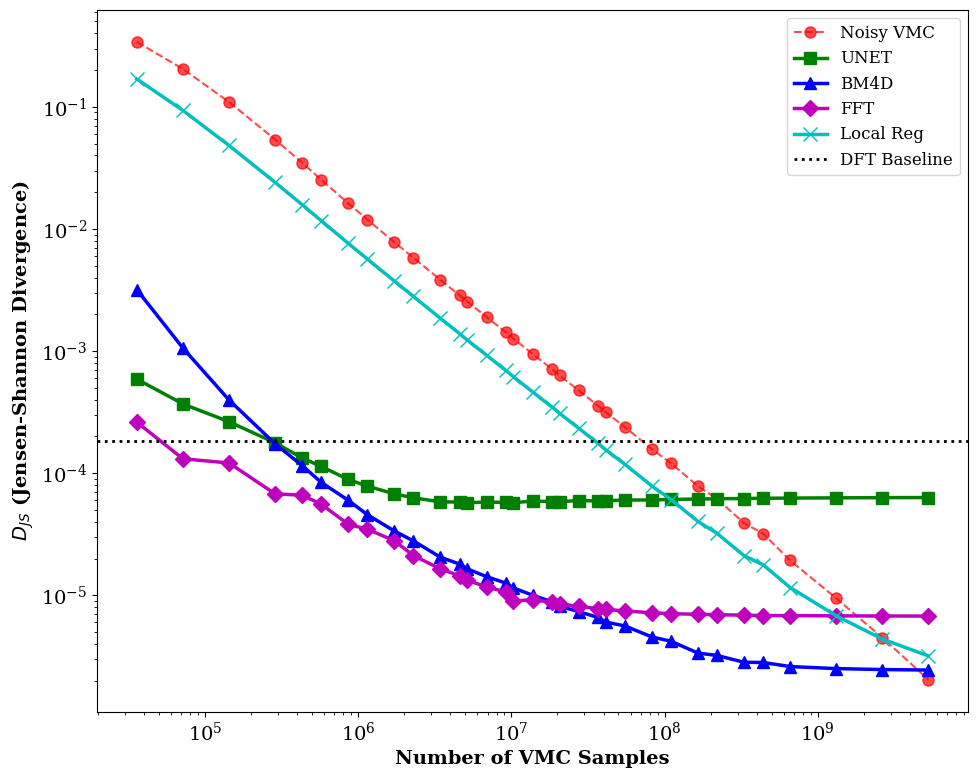

In [2]:
import os
import sys
import glob
import re
import logging
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd  # Added for CSV handling
from bm4d import bm4d

# --- Suppress Matplotlib Debug Output ---
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.ticker').setLevel(logging.WARNING)

# --- Path Setups ---
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil

# NOTE: Ensure D_JS is defined in your environment or imported
def D_JS(p1, p2, tol=1e-16):
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    pm = (p1 + p2) / 2
    p1_nonzero = np.abs(p1) > tol
    p2_nonzero = np.abs(p2) > tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5 * ( (p1 * np.log(p1 / pm1)).sum() + (p2 * np.log(p2 / pm2)).sum() )
    d /= np.log(2)
    return d

def local_polyfit(y, deg=1, window=3):
    """Local polynomial regression method"""
    N = len(y)
    half = window // 2  # <--- Fixed: divided by 2, not 'half'
    x = np.arange(N)
    y_out = np.zeros(N)

    for i in range(N):
        start = max(0, i - half)
        end   = min(N, i + half + 1)

        # local coordinates
        xi = x[start:end]
        yi = y[start:end]

        # fit polynomial to window
        coeffs = np.polyfit(xi, yi, deg)

        # predict at point i
        y_out[i] = np.polyval(coeffs, x[i])
    return y_out

def transform(density, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return (density - density_ref) / np.sqrt(np.abs(density_ref))
    raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return density_ref + np.sqrt(np.abs(density_ref)) * density_trans
    raise RuntimeError('bad transform type')

# --- 1. Load Reference Data ---
vmc_ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2/density_tot_ref_mean.h5'
with h5py.File(vmc_ref_path, 'r') as file:
    ref_d = file['density'][:]

dft_path = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

# --- 2. Setup Models ---
unet_model = tf.keras.models.load_model('/pscratch/sd/k/kberard/SCGSR/EDDA/BP/Density_Model/U-NET/residual_denoiser_40M_Blob_NODFT.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/bp_1x1x1_ccecp/density_data/vmc_J2'
files = glob.glob(os.path.join(data_dir, "density_tot_vmc_mean_*.h5"))
results = []
trans_type = 'residual_noise'
dm = DensityFourierFilterErrorCeil(density_ref=dft_d, filter_mode='augment')

# --- 3. Processing Loop ---
for fpath in files:
    print(fpath)
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    sigma_psd =1/np.sqrt(sample_count)
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # UNET
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, trans_type)
    pred_residual = unet_model.predict(input_residual, verbose=0)
    denoised_unet = np.maximum(inverse_transform(pred_residual, dft_reshaped, trans_type)[0, ..., 0], 0.0)

    # BM4D
    trans_d =transform(test_d, dft_d, trans_type)
    bm4d_raw = bm4d(trans_d, sigma_psd)
    bm4d_clean = inverse_transform(bm4d_raw, dft_d, trans_type)
    denoised_bm4d = np.maximum(bm4d_clean, 0.0)
    
    # FFT
    denoised_fft = dm.denoise(test_d)

    # Local Regression
    denoised_lr = np.maximum(local_polyfit(test_d.ravel(), deg=2, window=5).reshape(test_d.shape), 0.0)

    # Metrics
    results.append({
        "Samples": sample_count,
        "Noisy_VMC": D_JS(test_d, ref_d),
        "UNET": D_JS(denoised_unet, ref_d),
        "BM4D": D_JS(denoised_bm4d, ref_d),
        "FFT": D_JS(denoised_fft, ref_d),
        "Local_Reg": D_JS(denoised_lr, ref_d)
    })

# --- 4. Data Export & Plotting ---
df = pd.DataFrame(results).sort_values("Samples")
df.to_csv("denoising_performance_results.csv", index=False)
print("Results saved to denoising_performance_results.csv")

DFT_vs_DMC = D_JS(ref_d, dft_d)

# Plotting with Publication Settings
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df["Samples"], df["Noisy_VMC"], 'r--o', label='Noisy VMC', alpha=0.7, markersize=8)
ax.plot(df["Samples"], df["UNET"],      'g-s',  label='UNET', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["BM4D"],      'b-^',  label='BM4D', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["FFT"],       'm-D',  label='FFT', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["Local_Reg"], 'c-x',  label='Local Reg', linewidth=2.5, markersize=10)

ax.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT Baseline", linewidth=2)

# Log Scaling
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and Legibility
ax.set_xlabel('Number of VMC Samples', fontweight='bold')
ax.set_ylabel('$D_{JS}$ (Jensen-Shannon Divergence)', fontweight='bold')
ax.legend(frameon=True, loc='best', fontsize=12)
ax.grid(False)

plt.tight_layout()

# Save for Publication
plt.savefig("denoising_comparison_pub.png", dpi=300, bbox_inches='tight')
plt.savefig("denoising_comparison_pub.pdf", bbox_inches='tight')
plt.show()

In [ ]:
print("here")